In [1]:
import os
import random
import numpy as np
import cv2
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from sklearn.model_selection import train_test_split

In [2]:
def load_and_sample_images_weighted(base_path, total_samples):
    images = []
    labels = []
    class_names = []
    class_distributions = {}

    # Load all images and organize by class
    for label, folder in enumerate(sorted(os.listdir(base_path))):
        class_names.append(folder)
        folder_path = os.path.join(base_path, folder)
        class_images = []
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (128, 128))
            class_images.append(img.flatten())
        class_distributions[label] = class_images

    # Determine equal sample count per class
    num_classes = len(class_distributions)
    samples_per_class = total_samples // num_classes

    # Sample from each class equally (or as much as available)
    for label, imgs in class_distributions.items():
        sample_size = min(samples_per_class, len(imgs))
        sampled_images = random.sample(imgs, sample_size)
        images.extend(sampled_images)
        labels.extend([label] * sample_size)

    return np.array(images), np.array(labels), class_names


In [3]:
# --- Paths and sampling  ----------------------------------------
train_path = r"F:\fatemeh\phd\lesson\Linear Algebra\project\archive (4)\ECG_Image_data\train"
test_path  = r"F:\fatemeh\phd\lesson\Linear Algebra\project\archive (4)\ECG_Image_data\test"
total_train_samples, total_test_samples = 6000, 1200

X_train, y_train, class_names = load_and_sample_images_weighted(train_path, total_train_samples)
X_test,  y_test,  _           = load_and_sample_images_weighted(test_path,  total_test_samples)

print(f"[1] X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"[1] X_test  shape: {X_test.shape}, y_test  shape: {y_test.shape}")
print(f"[1] Classes: {class_names}")

# --- PCA-only pipeline ------------------------------------------------------
# Step 2: reduce dimensionality from 16 384 pixels to 50 principal components
print("[2] Performing PCA …")
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"[2] X_train_pca shape: {X_train_pca.shape}")
print(f"[2] X_test_pca  shape: {X_test_pca.shape}")

# --- Final feature matrices fed to the classifier --------------------------
X_train_final = X_train_pca     # 50 statistical features only
X_test_final  = X_test_pca

print(f"[3] Final X_train_final shape: {X_train_final.shape}")
print(f"[3] Final X_test_final  shape: {X_test_final.shape}")


[1] X_train shape: (5642, 16384), y_train shape: (5642,)
[1] X_test  shape: (1161, 16384), y_test  shape: (1161,)
[1] Classes: ['F', 'M', 'N', 'Q', 'S', 'V']
[2] Performing PCA …
[2] X_train_pca shape: (5642, 50)
[2] X_test_pca  shape: (1161, 50)
[3] Final X_train_final shape: (5642, 50)
[3] Final X_test_final  shape: (1161, 50)


In [4]:
# --- Build the MLP classifier for the PCA-only feature set ------------------
input_features = Input(shape=(X_train_final.shape[1],))   # X_train_final has 50 features
x = layers.Dense(128, activation='relu')(input_features)
x = layers.Dense(64,  activation='relu')(x)
x = layers.Dense(32,  activation='relu')(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=input_features, outputs=output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print(model.summary())

# --- Train and validate the model ------------------------------------------
model.fit(X_train_final, y_train,
          epochs=20,
          validation_data=(X_test_final, y_test),
          verbose=2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,062 (66.65 KB)

 Trainable params: 17,062 (66.65 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
177/177 - 1s - 7ms/step - accuracy: 0.7024 - loss: 10.2858 - val_accuracy: 0.8148 - val_loss: 2.4927
Epoch 2/20
177/177 - 0s - 1ms/step - accuracy: 0.8594 - loss: 1.4912 - val_accuracy: 0.8475 - val_loss: 1.6325
Epoch 3/20
177/177 - 0s - 1ms/step - accuracy: 0.9062 - loss: 0.7198 - val_accuracy: 0.8708 - val_loss: 1.3127
Epoch 4/20
177/177 - 0s - 1ms/step - accuracy: 0.9273 - loss: 0.4028 - val_accuracy: 0.8811 - val_loss: 1.2598
Epoch 5/20
177/177 - 0s - 1ms/step - accuracy: 0.9470 - loss: 0.2933 - val_accuracy: 0.8786 - val_loss: 1.1914
Epoch 6/20
177/177 - 0s - 1ms/step - accuracy: 0.9523 - loss: 0.2295 - val_accuracy: 0.8923 - val_loss: 1.1167
Epoch 7/20
177/177 - 0s - 1ms/step - accuracy: 0.9651 - loss: 0.1511 - val_accuracy: 0.9053 - val_loss: 1.0835
Epoch 8/20
177/177 - 0s - 1ms/step - accuracy: 0.9782 - loss: 0.0913 - val_accuracy: 0.9009 - val_loss: 1.1005
Epoch 9/20
177/177 - 0s - 1ms/step - accuracy: 0.9754 - loss: 0.1079 - val_accuracy: 0.9104 - val_loss: 1.

In [5]:
def predict_new_ecg(image_path: str) -> str:
    """
    Predict the arrhythmia class for a single ECG image using the PCA-only model.
    """
    # Load and preprocess the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image at: {image_path}")
    img = cv2.resize(img, (128, 128))

    # Flatten and project onto the PCA sub-space (50 features)
    img_flat = img.flatten().reshape(1, -1)   # shape (1, 16 384)
    img_pca  = pca.transform(img_flat)        # shape (1, 50)

    # Prediction
    pred_prob = model.predict(img_pca, verbose=0)
    pred_idx  = np.argmax(pred_prob, axis=1)[0]
    return class_names[pred_idx]



Test Accuracy: 0.9259

Classification Report:
              precision    recall  f1-score   support

           F       0.91      0.93      0.92       161
           M       0.93      0.94      0.93       200
           N       0.96      0.93      0.94       200
           Q       0.97      0.99      0.98       200
           S       0.87      0.90      0.88       200
           V       0.92      0.88      0.90       200

    accuracy                           0.93      1161
   macro avg       0.93      0.93      0.93      1161
weighted avg       0.93      0.93      0.93      1161



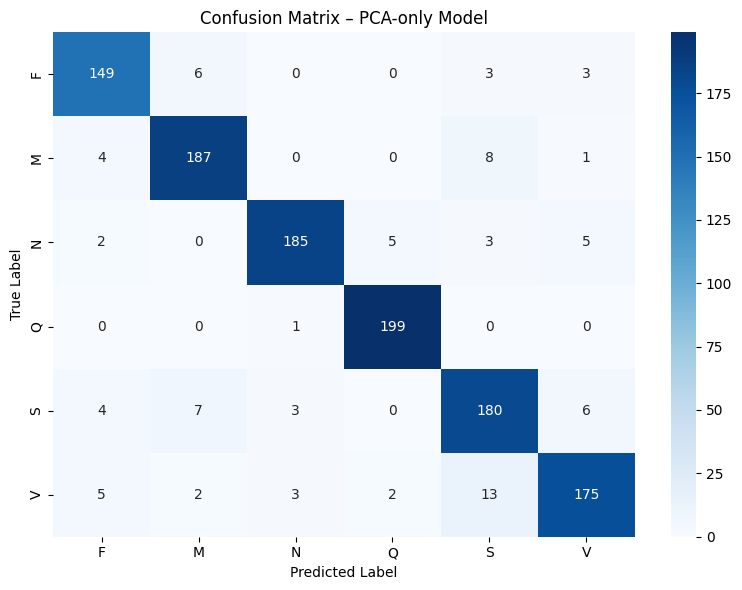

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Evaluate the PCA-only model
# ---------------------------------------------------------------------------

# Predictions on the test set (50-dimensional PCA features)
y_pred_probs  = model.predict(X_test_final, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues')
plt.title("Confusion Matrix – PCA-only Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [7]:
import ipywidgets as widgets
from IPython.display import display

# ---------------------------------------------------------------------------
# File-upload widget for the PCA-only model
# ---------------------------------------------------------------------------

upload_button = widgets.FileUpload(
    accept='.png, .jpg, .jpeg',  # allowed file types
    multiple=False               # single image at a time
)

def on_upload_change(change):
    """Handle a single ECG image uploaded via the widget and print its class."""
    for file_info in upload_button.value:
        print(f"File uploaded: {file_info['name']}")

        # Decode the image bytes to a NumPy array (grayscale)
        content      = file_info['content']
        image_array  = np.frombuffer(content, np.uint8)
        image        = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Error: Could not read the image.")
            return

        # Preprocess: resize to 128 × 128 and flatten
        img_resized = cv2.resize(image, (128, 128))
        img_flat    = img_resized.flatten().reshape(1, -1)     # shape (1, 16 384)

        # Project onto the PCA sub-space (50 features)
        img_pca = pca.transform(img_flat)                       # shape (1, 50)

        # Predict class
        prediction      = model.predict(img_pca, verbose=0)
        predicted_class = class_names[np.argmax(prediction)]

        print(f"Predicted Class: {predicted_class}")

# Connect the callback
upload_button.observe(on_upload_change, names='value')

# Display the widget
display(upload_button)


FileUpload(value=(), accept='.png, .jpg, .jpeg', description='Upload')

File uploaded: N52.png
Predicted Class: N
File uploaded: Q31.png
Predicted Class: Q
File uploaded: Q159.png
Predicted Class: Q
File uploaded: V96.png
Predicted Class: V
File uploaded: V261.png
Predicted Class: V
File uploaded: S95.png
Predicted Class: S
File uploaded: F123.png
Predicted Class: F


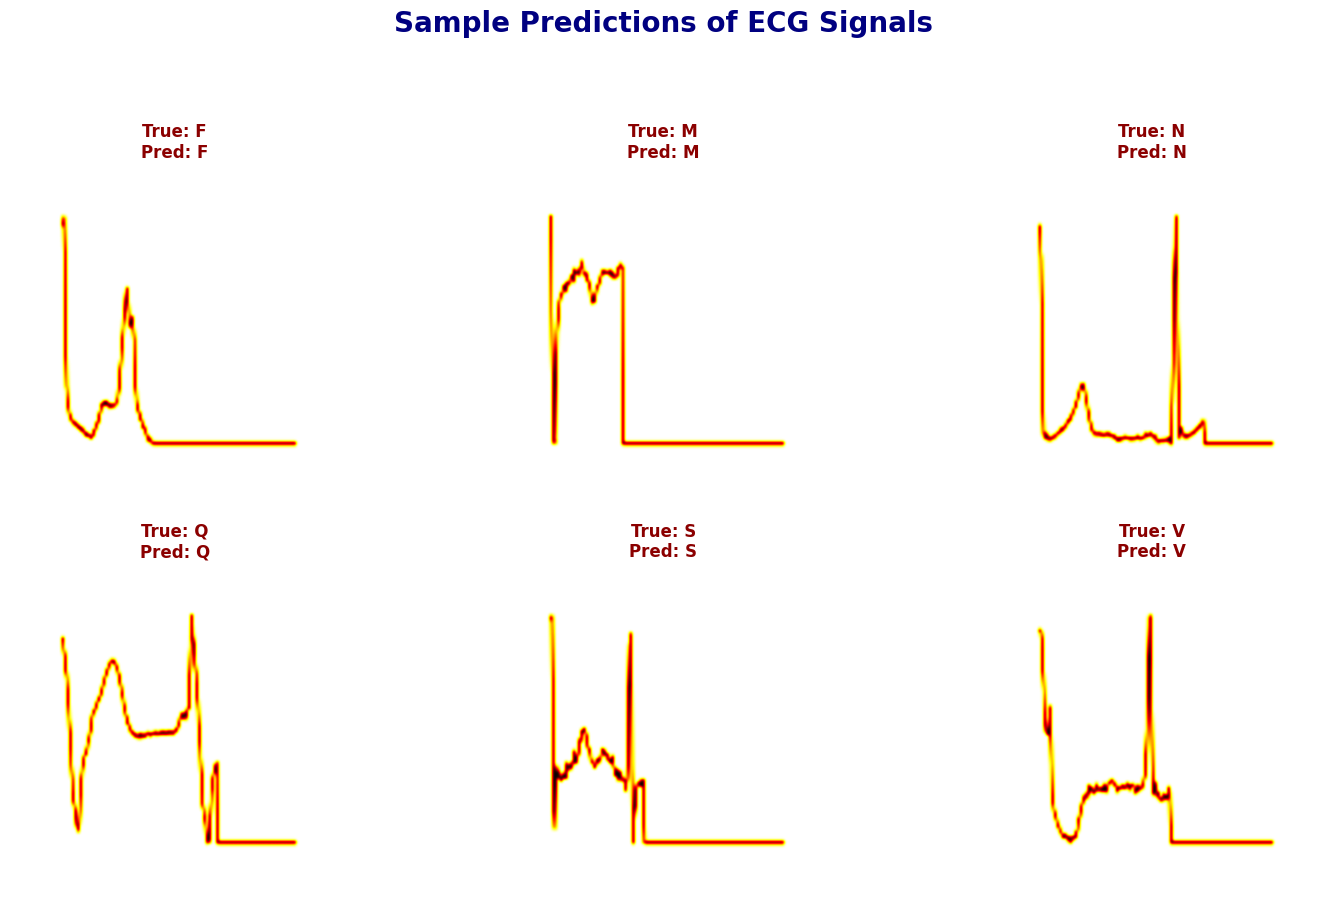

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_sample_predictions(images, labels, predictions, class_names,
                            n=6, rows=2, cols=3):
    """Display n sample ECG images together with true and predicted labels."""
    plt.figure(figsize=(15, 10))
    plt.suptitle('Sample Predictions of ECG Signals',
                 fontsize=20, color='navy', weight='bold', y=0.92)

    # Collect indices for each class
    class_samples = {i: [] for i in range(len(class_names))}
    for idx, lbl in enumerate(labels):
        class_samples[lbl].append(idx)

    # Pick (at most) one random index per class
    selected_indices = [np.random.choice(idxs)
                        for idxs in class_samples.values() if idxs][:n]

    # Plot images
    for i, idx in enumerate(selected_indices):
        plt.subplot(rows, cols, i + 1)
        img = images[idx].reshape(128, 128)
        plt.imshow(img, cmap='hot', interpolation='bicubic')

        plt.title(f"True: {class_names[labels[idx]]}\n"
                  f"Pred: {class_names[predictions[idx]]}",
                  fontsize=12, color='darkred', weight='bold')

        plt.axis('off')
        plt.gca().set_facecolor('#f7f7f7')
        for side in ['top', 'right', 'left', 'bottom']:
            plt.gca().spines[side].set_visible(False)

    plt.tight_layout(pad=2.5, rect=[0, 0, 1, 0.9])
    plt.show()


# ---------------------------------------------------------------------------
# Generate predictions with the PCA-only model and visualise a few samples
# ---------------------------------------------------------------------------
y_pred = np.argmax(model.predict(X_test_final, verbose=0), axis=1)

show_sample_predictions(images      = X_test,      # flattened raw images
                        labels      = y_test,
                        predictions = y_pred,
                        class_names = class_names,
                        n=6, rows=2, cols=3)


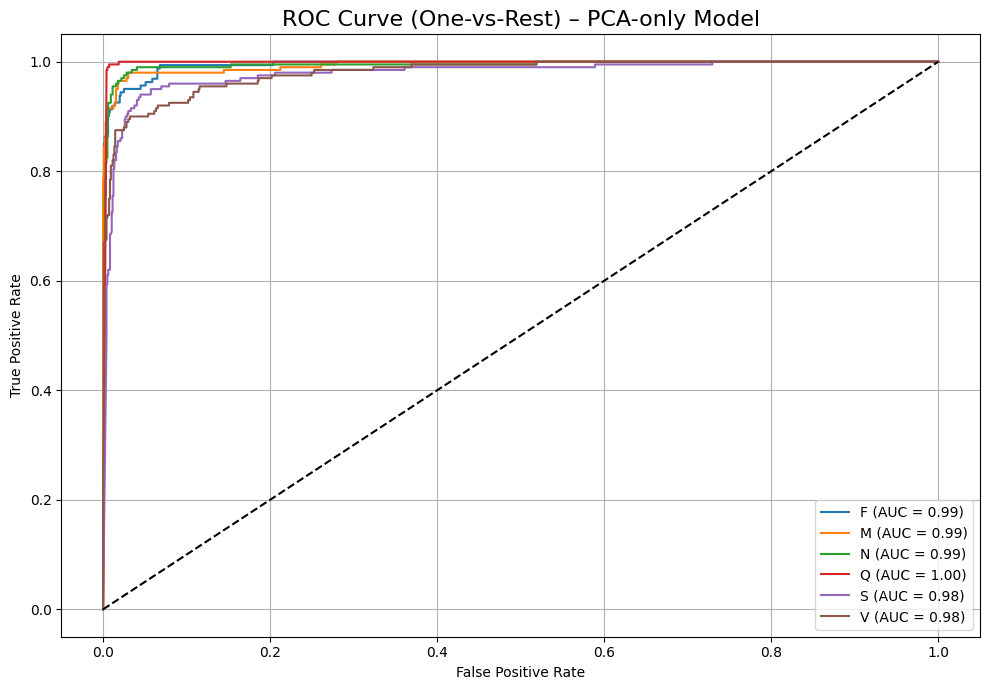

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np   # make sure NumPy is imported

# ---------------------------------------------------------------------------
# ROC curves (one-vs-rest) for the PCA-only model
# ---------------------------------------------------------------------------

# 1) Predicted probabilities for all classes
y_pred_probs = model.predict(X_test_final, verbose=0)      # ← PCA feature matrix

# 2) Binarise the ground-truth labels
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
n_classes  = y_test_bin.shape[1]

# 3) Compute ROC curves and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# 4) Plot
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest) – PCA-only Model', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
y_pred = np.argmax(model.predict(X_test_final, verbose=0), axis=1)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc*100:.2f}%")

Balanced Accuracy: 92.59%
